# Woody Hayes Dr. Construction Analysis

This notebook is intended to analyze if the lane restrictions on Woody Hayes Dr. starting on March 26, 2026 have impacted metrics for the medical center shuttle.


---

### Background:

On March 26th, 2026, Woody Hayes Dr. between Kenny Rd. and John H Herrick Dr. was reduced from 2 eastbound lanes and 2 westbound lanes with a center median, to 1 lane each direction. This is due to construction occuring on the adjacent lot intended to end in mid June 2026. The following questions intend to be answered by this analysis:

1) Has this lane restriction caused a change in travel time for the med center express shuttle?
2) Are buses 'bunching' due to traffic in the area?
    - This will be defined by close arrival times of multiple busses, or rather how spread out the busses appear to be in terms of arrival time.

### Relevant Information:

Busstate data for this analysis was pulled on 4/29/2026 and is stored at the following file path:

`../WMC_Dashboard/analysis_data/woody_hayes/`

This includes busstate data from February - April 2026

---

### Setup:

In [1]:
# Lane restriction was implemented at some point on 3/36/2026
# Going to pull in data and split around this date for before and after analysis

# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import importlib

In [2]:
# go up one level from notebook folder
sys.path.append(os.path.abspath(".."))

from modules import med_center_dashboard as mcd
importlib.reload(mcd)

repo_dir = "K:/AP/TTM/Data/WMC_Dashboard/analysis_data/woody_hayes"

# month and date dict
timeframe_dict = {
    # 'JAN': 2026,
    'FEB': 2026,
    'MAR': 2026,
    'APR': 2026
}

# loop through and concat to once single df
df = pd.DataFrame()
for month, year in timeframe_dict.items():
    df = pd.concat([df, mcd.process_mc_busstate(year=year, month=month, current_dir=repo_dir)], ignore_index=True)

# This should only have to be run once per session. ~9 minutes to run

In [3]:
# split into before and after timeframes with equal number of days on either side
# not inclusive of 3/26/2026 as the lane restriction could have been implemented at any point during that day
before_df = df[(df['DATE'] >= '2026-02-25') & (df['DATE'] < '2026-03-26')] # 21 business days 2/25 - 3/25
after_df = df[(df['DATE'] > '2026-03-26') & (df['DATE'] <= '2026-04-24')] # 21 business days 3/27 - 4/24

In [4]:
print(f'Before lane restriction: {len(before_df)} records')
print(f'After lane restriction: {len(after_df)} records') # even out records

Before lane restriction: 34574 records
After lane restriction: 34779 records


Records are roughly even

---

### Has the lane restriction led to a change in travel times?

Specifically in the ~3-5pm hour

In [5]:
# import travel_time module as initial check
from modules import travel_time 

before_travel_time = travel_time.create_travel_time(before_df)
after_travel_time = travel_time.create_travel_time(after_df)

print("Before lane restriction travel time stats:")
display(before_travel_time)

print("After lane restriction travel time stats:")
display(after_travel_time)

Before lane restriction travel time stats:


,TIME,LOOPS,CARMACK 2 - UH/DOAN,UH/DOAN - CARMACK 2
0,5:30-7a,803,7.9,6.5
1,7-10a,1025,10.8,7.0
2,10a-4p,1264,10.3,6.7
3,4-7p,1027,10.2,6.5
4,7p-12a,1163,10.0,5.8
5,12-5a,403,9.5,5.4


After lane restriction travel time stats:


,TIME,LOOPS,CARMACK 2 - UH/DOAN,UH/DOAN - CARMACK 2
0,5:30-7a,808,7.9,6.4
1,7-10a,991,10.8,7.0
2,10a-4p,1280,10.2,7.0
3,4-7p,1022,10.3,7.9
4,7p-12a,1231,10.0,5.9
5,12-5a,401,9.7,5.5


Initial look given my existing module. Travel time appear to be about the same with a decent increase in the travel time specifically in the 4pm-7pm outbound timeframe. The 10a-4p timeframe also has a slight increase in time.


---

Isolating the outbound travel, timedelta of Doan Hall departure to Carmack 2 arrival

**Statistical Testing**

`H0`: mean travel time before lane closure = mean travel time after lane closure

`HA`: Mean travel time after > mean travel time before
- This is one sided since we care specifically about increases here due to roadway congestion

In [27]:
# df already has hour buckets

before_df.info() # 37 is Doan Hall, 401 is Carmack 2

# specifically want the travel time from departure of Doan Hall to arrival at Carmack 2
# before_outbound_df = before_df

<class 'pandas.DataFrame'>
Index: 34574 entries, 1227 to 67644
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype          
---  ------               --------------  -----          
 0   BUS_ID               34574 non-null  int64          
 1   DATE                 34574 non-null  datetime64[us] 
 2   COUNT                34574 non-null  int64          
 3   STOP_ID              34574 non-null  int64          
 4   BOARDINGS            34574 non-null  float64        
 5   ALIGHTINGS           34574 non-null  float64        
 6   LOAD                 34574 non-null  int64          
 7   RUN_ID               34574 non-null  float64        
 8   DEST                 34574 non-null  str            
 9   ARRIVAL              34574 non-null  datetime64[us] 
 10  DEPARTURE            34574 non-null  datetime64[us] 
 11  DWELL                34574 non-null  timedelta64[us]
 12  HOUR                 34574 non-null  int32          
 13  MINUTE               34574 no

In [98]:
# create a df with only CM2 and Doan Hall records for outbound analysis
DOAN_ID = 37
CARMACK_2_ID = 403

before_outbound_df = before_df[(before_df['STOP_ID'] == DOAN_ID) | (before_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
before_outbound_df = before_outbound_df.drop(columns=['LOAD', 'DEST']) 

# sort by bus and time
before_outbound_df = before_outbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (before_outbound_df['BUS_ID'] == before_outbound_df['BUS_ID'].shift(1))
    & (before_outbound_df['DATE'] == before_outbound_df['DATE'].shift(1))
    & (before_outbound_df['RUN_ID'] == before_outbound_df['RUN_ID'].shift(1))
    & (before_outbound_df['STOP_ID'].shift(1) == DOAN_ID) # only calculate run time if previous record was Doan Hall
)

before_outbound_df['RUN_TIME'] = np.where(
    same_trip,
    (before_outbound_df['ARRIVAL'] - before_outbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 20 minutes 
before_outbound_df = before_outbound_df[(before_outbound_df['RUN_TIME'] >= 3) & (before_outbound_df['RUN_TIME'] <= 20)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 20 is likely an outlier

# drop OB rows only want outbound trips
before_outbound_df = before_outbound_df[before_outbound_df['STOP_ID'] == CARMACK_2_ID]

display(before_outbound_df.head(3))


#----------------------------------
# Repeat for after lane restriction
after_outbound_df = after_df[(after_df['STOP_ID'] == DOAN_ID) | (after_df['STOP_ID'] == CARMACK_2_ID)]
# drop unnecessary columns
after_outbound_df = after_outbound_df.drop(columns=['LOAD', 'DEST']) 

# sort by bus and time
after_outbound_df = after_outbound_df.sort_values(by=['RUN_ID', 'TIME']).reset_index(drop=True)

same_trip = ( # boolean mask to id records part of same trip
    (after_outbound_df['BUS_ID'] == after_outbound_df['BUS_ID'].shift(1))
    & (after_outbound_df['DATE'] == after_outbound_df['DATE'].shift(1))
    & (after_outbound_df['RUN_ID'] == after_outbound_df['RUN_ID'].shift(1))
    & (after_outbound_df['STOP_ID'].shift(1) == DOAN_ID) # only calculate run time if previous record was Doan Hall
)

after_outbound_df['RUN_TIME'] = np.where(
    same_trip,
    (after_outbound_df['ARRIVAL'] - after_outbound_df['DEPARTURE'].shift(1)).dt.total_seconds() / 60,
    np.nan
)

# filter out any negative or unrealistic run times OR > 30
after_outbound_df = after_outbound_df[(after_outbound_df['RUN_TIME'] >= 3) & (after_outbound_df['RUN_TIME'] <= 20)]
# according to google maps, 5 minutes travel time without traffic and assuming no red lights, anything under 3 is impossible and anything over 20 is likely an outlier

# drop OB rows only want outbound trips
after_outbound_df = after_outbound_df[after_outbound_df['STOP_ID'] == CARMACK_2_ID]

display(after_outbound_df.head(3))


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
2,2104,2026-02-25,21191,403,7.0,1.0,1501.0,1900-01-01 05:11:36,1900-01-01 05:14:35,0 days 00:02:59,5,11,IB,2026-02-25 05:11:36,5.533333
4,2104,2026-02-25,21195,403,22.0,1.0,1501.0,1900-01-01 05:31:15,1900-01-01 05:35:29,0 days 00:04:14,5,31,IB,2026-02-25 05:31:15,5.166667
6,2104,2026-02-25,21199,403,4.0,0.0,1501.0,1900-01-01 05:50:36,1900-01-01 05:52:36,0 days 00:02:00,5,50,IB,2026-02-25 05:50:36,5.916667


,BUS_ID,DATE,COUNT,STOP_ID,BOARDINGS,ALIGHTINGS,RUN_ID,ARRIVAL,DEPARTURE,DWELL,HOUR,MINUTE,BOARDING_DIRECTIONS,TIME,RUN_TIME
3,2501,2026-03-27,26681,403,6.0,0.0,1501.0,1900-01-01 05:14:06,1900-01-01 05:14:51,0 days 00:00:45,5,14,IB,2026-03-27 05:14:06,4.800000
5,2501,2026-03-27,26685,403,11.0,1.0,1501.0,1900-01-01 05:32:02,1900-01-01 05:33:55,0 days 00:01:53,5,32,IB,2026-03-27 05:32:02,6.983333
7,2501,2026-03-27,26689,403,4.0,2.0,1501.0,1900-01-01 05:50:22,1900-01-01 05:52:57,0 days 00:02:35,5,50,IB,2026-03-27 05:50:22,5.416667


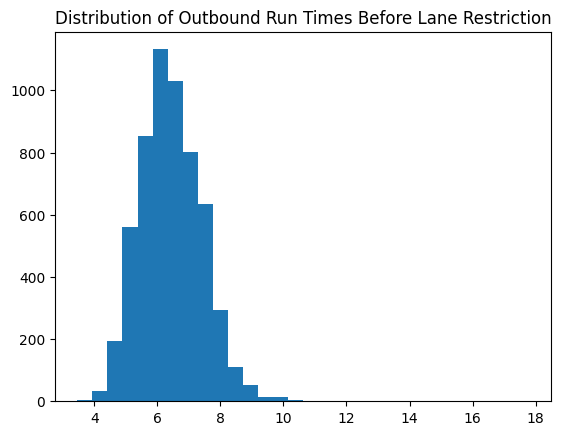

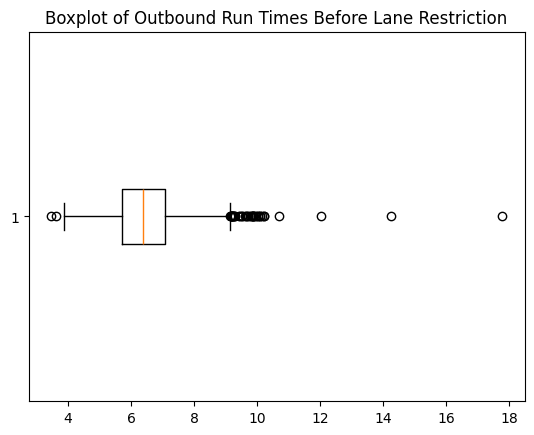

In [99]:
# determine the level of skew in the outbound run_time data
plt.hist(before_outbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Outbound Run Times Before Lane Restriction')
plt.show()

plt.boxplot(before_outbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Outbound Run Times Before Lane Restriction')
plt.show()

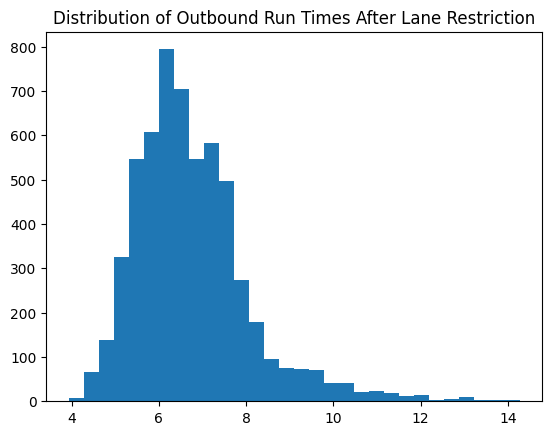

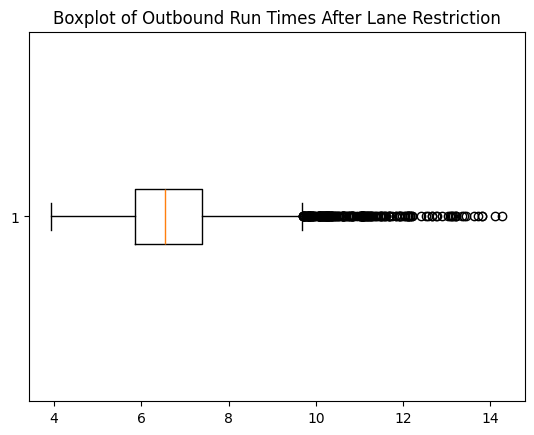

In [100]:
# determine the level of skew in the outbound run_time data
plt.hist(after_outbound_df['RUN_TIME'], bins=30)
plt.title('Distribution of Outbound Run Times After Lane Restriction')
plt.show()

plt.boxplot(after_outbound_df['RUN_TIME'], vert=False)
plt.title('Boxplot of Outbound Run Times After Lane Restriction')
plt.show()


---

### Notes: 

- The data has not been transformed with a log, but maintains right skew.
- Attempt a single regression model with categorical hour bins. This avoids the potential small sample instability per hour with an individual Mann-Whitney test for each hour. This allows for a much cleaner interpretation and more statistical power.
- Model will estimate the following:
    1) Average shift after construction 
    2) Hourly fixed effects, normal daily patterns
    3) Interaction between the 2, how much did the travel time change in this specific hour after the lane restriction was put in place?

In [106]:
import statsmodels.formula.api as smf

# combine before and after data for regression analysis
outbound_df = pd.concat([before_outbound_df, after_outbound_df], ignore_index=True)
outbound_df['post_period'] = (outbound_df['DATE'] >= '2026-03-26').astype(int) # binary variable for before/after lane restriction

model = smf.ols(
formula='RUN_TIME ~ post_period + C(HOUR) + post_period:C(HOUR)',
data=outbound_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               RUN_TIME   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     163.9
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:52:21   Log-Likelihood:                -15293.
No. Observations:               11511   AIC:                         3.068e+04
Df Residuals:                   11463   BIC:                         3.104e+04
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [114]:
results = model.summary2().tables[1].reset_index()
results.columns = ['term', 'coef', 'std_err', 't', 'p_value', 'ci_low', 'ci_high']

# Filter only interaction terms
hour_effects = results[results['term'].str.contains('post_period:C\\(HOUR\\)')]

# Extract hour number
hour_effects['hour'] = hour_effects['term'].str.extract(r'T\.(\d+)').astype(int)

# Sort by hour
hour_effects = hour_effects.sort_values('hour')

# get rid of sci notattion, but keep very small p-values as <0.000001
hour_effects['p_value'] = hour_effects['p_value'].apply(lambda x: f"{x:.6f}" if x > 1e-6 else "<0.000001")

print(hour_effects[['hour', 'coef', 'p_value']])

    hour      coef    p_value
25     1  0.041632   0.843347
26     2  0.144677   0.496323
27     3  0.124159   0.557089
28     4  0.015339   0.935991
29     5 -0.223429   0.208149
30     6 -0.199288   0.193374
31     7 -0.082336   0.599421
32     8 -0.047900   0.765992
33     9 -0.080512   0.646633
34    10  0.088210   0.615965
35    11  0.116000   0.515460
36    12  0.192215   0.278397
37    13  0.077344   0.662717
38    14  0.193007   0.240173
39    15  0.253452   0.116601
40    16  1.677636  <0.000001
41    17  2.141209  <0.000001
42    18  0.226820   0.157824
43    19 -0.032958   0.838330
44    20  0.074536   0.664305
45    21 -0.019131   0.912361
46    22  0.046577   0.780665
47    23 -0.005372   0.974607


**Coefficient** represents the change in travel time at the given hour after the lane restriction in minutes

- A p value of < 0.05 is considered statistically significant
- Hour 1600 and 1700 indicate a ~1.6 and ~2.1 minute increase in travel time respectively
- This is extremely strong statistical evidence that travel time has increased in this timeframe
- Other hours have small coefficients and large p values, this indicates no statistically meaningful change

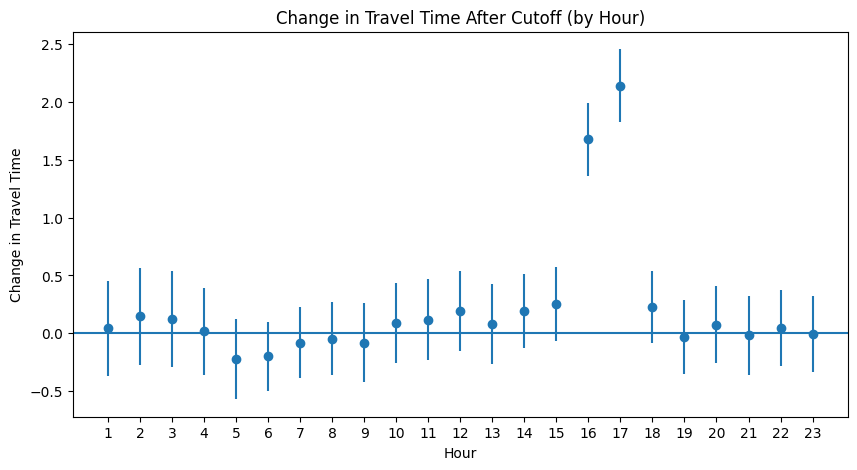

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.axhline(0)

plt.errorbar(
    hour_effects['hour'],
    hour_effects['coef'],
    yerr=1.96 * hour_effects['std_err'],
    fmt='o'
)

plt.title("Change in Travel Time After Lane Restriction (by Hour)")
plt.xlabel("Hour")
plt.xticks(hour_effects['hour'])
plt.ylabel("Change in Travel Time")
plt.show()

## Final Interpretation of Outbound Travel Time Increase:

After the lane restriction on Woody Hayes drive, there is a statistically significant increase in travel time in the 1600 and 1700 hours. Visually you can see the confidence intervals do not cross 0 which is key. Everything else is within the range of 0 indicating no effect. 

Outbound travel time for this test is considered the timedelta of the departure of Doan Hall to arrival at Carmack 2. At 4pm and 5pm there is a ~1.6 and ~2.1 minute increase in outbound travel time respectively. There is strong evidence that the observed changes are not due to random variation.

The lane restriction on Woody Hayes Dr. has led to a statistically significant and meaningful increase in the outbound travel times during the afternoon peak of 4-5pm, and has led to minimal impact on the outbound travel during other times of the day.

---


### Inbound Travel Times

Based on the prior testing, I do not expect significant results in terms of travel time increasing for inbound traffic.

Isolating the inbound travel, timedelta of Carmack 2 departure to University Hospital arrival

**Statistical Testing**

`H0`: mean travel time before lane closure = mean travel time after lane closure

`HA`: Mean travel time after > mean travel time before
- This is one sided since we care specifically about increases here due to roadway congestion

In [ ]:
# testing the inbound run times to see if there is any significant increase

